# Book - Modern Time Series Forecasting with Python

## Chapter 13 - Model Evaluation, Selection, and Ensembling


### Python version 3.8

### Libraries version
* matplotlib: 3.7.1
* pandas: 2.0.3
* numpy: 1.23.5
* sklearn: 1.3.2
* seaborn: 0.13.2
* statsmodels: 0.14.1
* tensorflow: 2.12.0
* keras: 2.12.0

### <span style="color:blue">01. Forecasting Error Metrics

#### Load libraiies

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Set a consistent style for plots
plt.style.use('seaborn-v0_8-whitegrid')


#### Create Sample Actual and Forecasted Data

In [18]:
# --- Create Sample Actual and Forecasted Data ---
np.random.seed(42)
n_points = 50
time_idx = pd.date_range(start='2023-01-01', periods=n_points, freq='D')
actuals = pd.Series(100 + 0.5 * np.arange(n_points) + np.random.randn(n_points) * 5, index=time_idx)
# Create forecasts with some error
forecasts = actuals + np.random.normal(0, 8, n_points)
# Introduce a large outlier error
forecasts.iloc[30] = forecasts.iloc[30] + 30

#### Calculate Forecast Error

In [19]:
# --- Calculate Forecast Errors ---
errors = actuals - forecasts


#### Calculate Scale-Dependent Metrics

In [21]:
# --- Calculate Scale-Dependent Metrics ---
mae = mean_absolute_error(actuals, forecasts)
mse = mean_squared_error(actuals, forecasts)
rmse = np.sqrt(mse)


print("--- Scale-Dependent Error Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

--- Scale-Dependent Error Metrics ---
Mean Absolute Error (MAE): 5.9631
Mean Squared Error (MSE): 63.8573
Root Mean Squared Error (RMSE): 7.9911


#### Calculate Percentage Errors

In [22]:
# --- Calculate Percentage Errors ---
# MAPE requires strictly positive actuals
mape = mean_absolute_percentage_error(actuals, forecasts) * 100
# sMAPE calculation
smape = np.mean(2 * np.abs(forecasts - actuals) / (np.abs(actuals) + np.abs(forecasts))) * 100

print("\n--- Percentage Error Metrics ---")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Symmetric MAPE (sMAPE): {smape:.2f}%")


--- Percentage Error Metrics ---
Mean Absolute Percentage Error (MAPE): 5.42%
Symmetric MAPE (sMAPE): 5.39%


#### Calculate Scaled Error (MASE) 

In [23]:
# --- Calculate Scaled Error (MASE) ---
# Requires in-sample data for the naive error calculation
# Let's assume the first 40 points were "training" for the naive model
train_actuals = actuals.iloc[:40]
in_sample_naive_mae = mean_absolute_error(train_actuals.iloc[1:], train_actuals.iloc[:-1])
# Calculate MAE on the "test" set (last 10 points)
test_actuals = actuals.iloc[40:]
test_forecasts = forecasts.iloc[40:]
out_of_sample_mae = mean_absolute_error(test_actuals, test_forecasts)
mase = out_of_sample_mae / in_sample_naive_mae

print("\n--- Scaled Error Metric (on last 10 points) ---")
print(f"In-sample Naive MAE: {in_sample_naive_mae:.4f}")
print(f"Out-of-sample Model MAE: {out_of_sample_mae:.4f}")
print(f"Mean Absolute Scaled Error (MASE): {mase:.4f}")




--- Scaled Error Metric (on last 10 points) ---
In-sample Naive MAE: 5.8034
Out-of-sample Model MAE: 3.7983
Mean Absolute Scaled Error (MASE): 0.6545


#### Visualize Forecasts and Errors

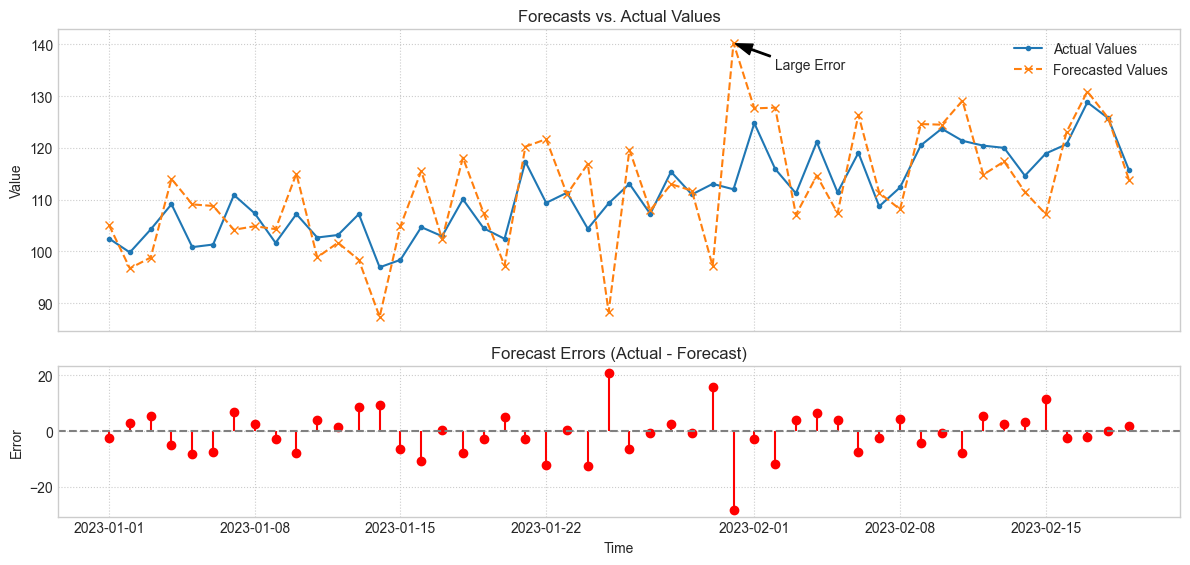

In [29]:
# --- Visualize Forecasts and Errors ---
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle('Forecast Evaluation and Error Analysis', fontsize=16)

# Plot forecasts vs. actuals
axes[0].plot(actuals, label='Actual Values', marker='.', linestyle='-')
axes[0].plot(forecasts, label='Forecasted Values', marker='x', linestyle='--')
axes[0].set_title('Forecasts vs. Actual Values')
axes[0].set_ylabel('Value')
axes[0].legend()
axes[0].grid(True, linestyle=':')
# Highlight the outlier
axes[0].annotate('Large Error', xy=(forecasts.index[30], forecasts.iloc[30]),
                 xytext=(forecasts.index[30] + pd.Timedelta(days=2), forecasts.iloc[30] - 5),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))


# Plot forecast errors
axes[1].stem(errors.index, errors, basefmt=" ", linefmt='-r', markerfmt='or')
axes[1].axhline(0, color='grey', linestyle='--')
axes[1].set_title('Forecast Errors (Actual - Forecast)')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Error')
axes[1].grid(True, linestyle=':')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### <span style="color:blue">02.Backtesting and Walk-Forward Validation


#### Load dataset

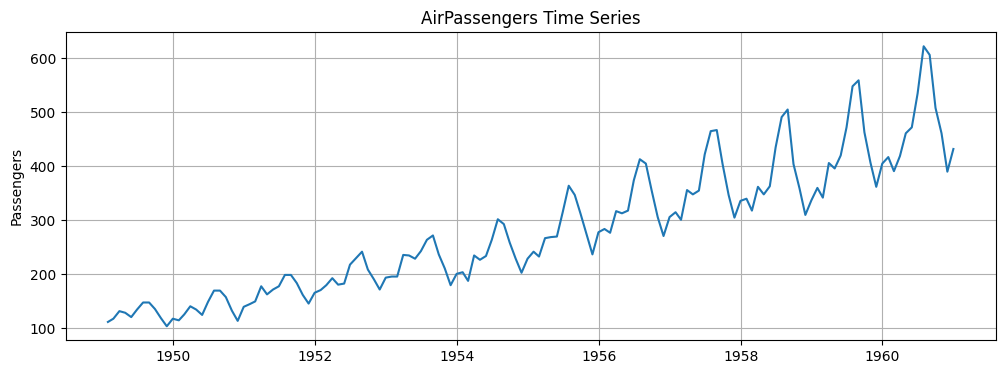

In [5]:
data = sm.datasets.get_rdataset("AirPassengers", "datasets", cache=True).data

ts = data['value']
ts.index = pd.date_range(start='1949-01', periods=len(ts), freq='M')

plt.figure(figsize=(12,4))
plt.plot(ts)
plt.title("AirPassengers Time Series")
plt.ylabel("Passengers")
plt.grid(True)
plt.show()

#### Fixed-Origin Backtest (Expanding Window)

In [6]:
def expanding_window_backtest(series, train_size, horizon):
    """
    Train on expanding window and forecast fixed horizon.
    """
    mae_scores = []
    forecasts = []
    actuals = []

    for i in range(train_size, len(series)-horizon):
        train = series[:i]
        test = series[i:i+horizon]

        model = ARIMA(train, order=(2,1,2)).fit()
        forecast = model.forecast(steps=horizon)

        mae_scores.append(mean_absolute_error(test, forecast))
        forecasts.append(forecast.values)
        actuals.append(test.values)

    return mae_scores, forecasts, actuals

train_size = int(len(ts) * 0.6)   # first 60% as initial training
horizon = 1                       # one-step forecasting

mae_expanding, forecasts_exp, actuals_exp = expanding_window_backtest(ts, train_size, horizon)

print("Expanding-Window MAE (mean):", np.mean(mae_expanding))

Expanding-Window MAE (mean): 33.539302402567195


#### Plot Expanding-Window MAE Over Time

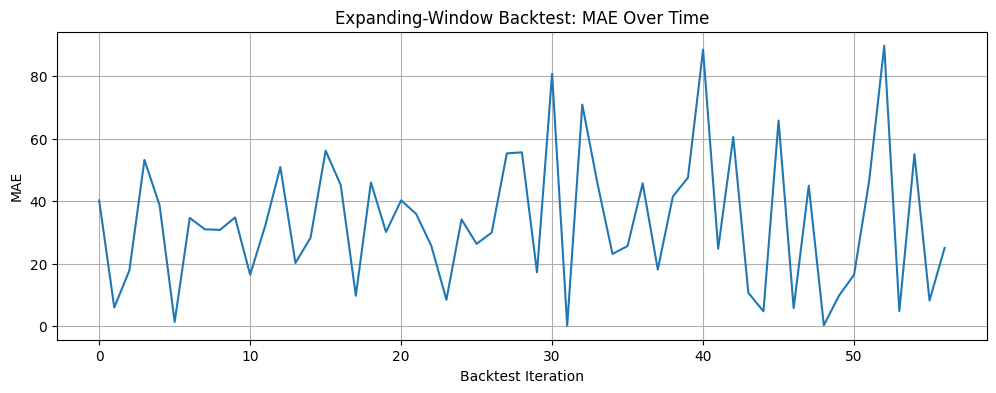

In [8]:
plt.figure(figsize=(12,4))
plt.plot(mae_expanding)
plt.title("Expanding-Window Backtest: MAE Over Time")
plt.xlabel("Backtest Iteration")
plt.ylabel("MAE")
plt.grid(True)
plt.show()

#### Sliding-Window Backtesting

In [9]:
def sliding_window_backtest(series, window_size, horizon):
    mae_scores = []
    forecasts = []
    actuals = []

    for i in range(window_size, len(series)-horizon):
        train = series[i-window_size:i]
        test = series[i:i+horizon]

        model = ARIMA(train, order=(2,1,2)).fit()
        forecast = model.forecast(steps=horizon)

        mae_scores.append(mean_absolute_error(test, forecast))
        forecasts.append(forecast.values)
        actuals.append(test.values)

    return mae_scores, forecasts, actuals

window_size = 48  # train on last 4 years
horizon = 1

mae_sliding, forecasts_slid, actuals_slid = sliding_window_backtest(ts, window_size, horizon)
print("Sliding-Window MAE (mean):", np.mean(mae_sliding))

Sliding-Window MAE (mean): 29.243705365770438


#### Plot Sliding-Window MAE Over Time

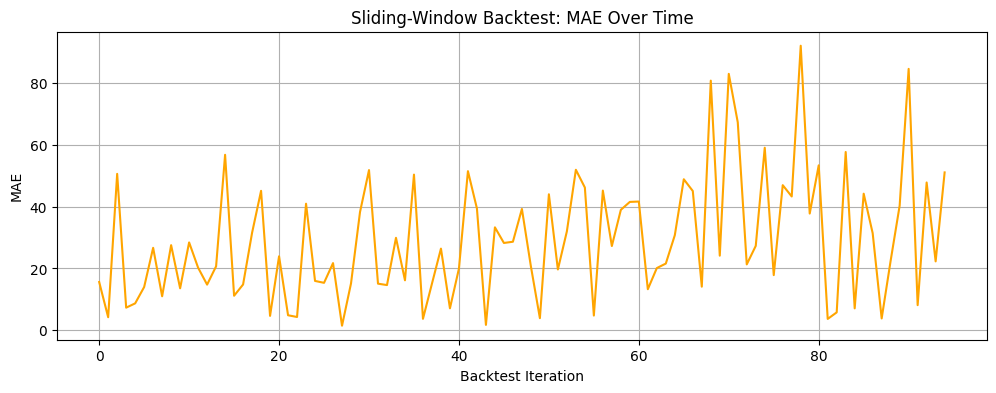

In [11]:
plt.figure(figsize=(12,4))
plt.plot(mae_sliding, color='orange')
plt.title("Sliding-Window Backtest: MAE Over Time")
plt.xlabel("Backtest Iteration")
plt.ylabel("MAE")
plt.grid(True)
plt.show()

#### Multi-Step Walk-Forward Validation (Recursive Forecasting)


In [13]:
def walk_forward_forecast(series, train_size, horizon):
    train = series[:train_size]
    test = series[train_size:]

    predictions = []
    actuals = []

    for i in range(len(test)):
        model = ARIMA(train, order=(2,1,2)).fit()
        pred = model.forecast(steps=1)[0]

        predictions.append(pred)
        actuals.append(test[i])

        # expand training window
        train = pd.concat([train, pd.Series([test[i]], index=[test.index[i]])])

    return np.array(predictions), np.array(actuals)

train_size = int(len(ts) * 0.7)
preds, actuals = walk_forward_forecast(ts, train_size, horizon=1)

mae_walk = mean_absolute_error(actuals, preds)
print("Walk-Forward MAE:", mae_walk)

Walk-Forward MAE: 35.64161803531329


#### Plot Walk-Forward Forecast vs Actual

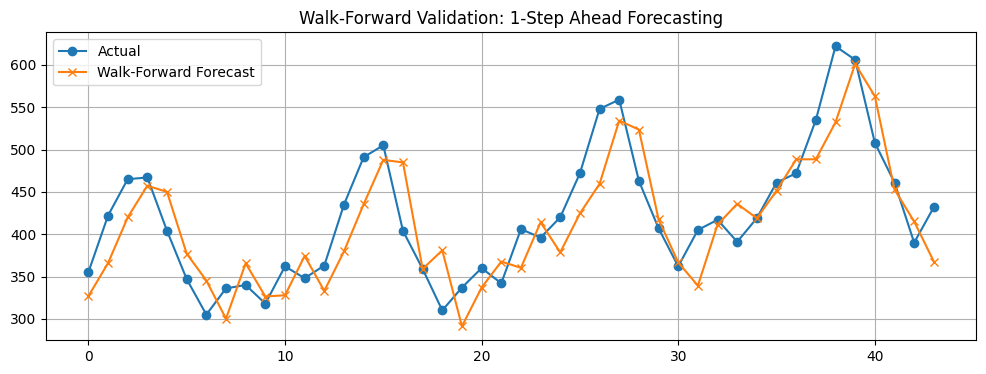

In [14]:
plt.figure(figsize=(12,4))
plt.plot(actuals, label="Actual", marker='o')
plt.plot(preds, label="Walk-Forward Forecast", marker='x')
plt.title("Walk-Forward Validation: 1-Step Ahead Forecasting")
plt.legend()
plt.grid(True)
plt.show()

### <span style="color:blue">03. Diebold–Mariano Test (Comparing Forecast Accuracy)

#### Load libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import t
# Set a consistent style for plots
plt.style.use('seaborn-v0_8-whitegrid')


#### Define the function

In [32]:
def diebold_mariano_test(e1, e2, h=1, power=2, alternative="two-sided"):
    """
    Diebold-Mariano test for predictive accuracy.
    
    Parameters
    ----------
    e1, e2 : array-like
        Forecast errors from two models.
    h : int
        Forecast horizon.
    power : int
        Loss function power. 1 = absolute error, 2 = squared error.
    alternative : str
        'two-sided', 'less', or 'greater'.
        
    Returns
    -------
    DM statistic, p-value
    """
    e1, e2 = np.asarray(e1), np.asarray(e2)
    
    # Loss differential
    d = np.abs(e1)**power - np.abs(e2)**power
    
    mean_d = np.mean(d)
    n = len(d)
    
    # Variance estimation (Newey-West with lag=h-1)
    def autocov(x, lag):
        return np.cov(x[:-lag], x[lag:])[0,1] if lag < len(x) else 0
    
    gamma = [autocov(d, lag) for lag in range(1, h)]
    var_d = (np.var(d, ddof=1) + 2 * np.sum(gamma)) / n
    
    dm_stat = mean_d / np.sqrt(var_d)
    
    # Small sample adjustment (Harvey et al. 1997)
    k = ((n+1-2*h+h)/(n))
    dm_stat_adj = np.sqrt(k) * dm_stat
    
    # p-value
    if alternative == "two-sided":
        p_value = 2 * (1 - t.cdf(np.abs(dm_stat_adj), df=n-1))
    elif alternative == "greater":
        p_value = 1 - t.cdf(dm_stat_adj, df=n-1)
    else:  # 'less'
        p_value = t.cdf(dm_stat_adj, df=n-1)
    
    return dm_stat_adj, p_value




#### Create Sample Actuals and Two Competing Forecasts

In [39]:
#  Create Sample Actuals and Two Competing Forecasts ---
np.random.seed(42)
n_points = 100
time_idx = pd.date_range(start='2023-01-01', periods=n_points, freq='D')
actuals = pd.Series(100 + 0.2 * np.arange(n_points) + np.random.randn(n_points) * 5, index=time_idx)


In [40]:

# (Model A): Slightly higher error
forecast_A = actuals + np.random.normal(0, 7, n_points)
#  (Model B): Slightly lower error
forecast_B = actuals + np.random.normal(0, 6, n_points)


#### Calculate Forecast Errors 

In [41]:
# Calculate Forecast Errors ---
errors_A = actuals - forecast_A
errors_B = actuals - forecast_B


#### Perform the Diebold-Mariano Test

In [42]:
#  Perform the Diebold-Mariano Test ---
print("\n--- Diebold-Mariano Test ---")
dm_statistic, dm_p_value = diebold_mariano_test(errors_A, errors_B, h=1, power=2, alternative="two-sided")

print(f"DM Statistic: {dm_statistic:.4f}")
print(f"P-value (two-sided): {dm_p_value:.4f}")



--- Diebold-Mariano Test ---
DM Statistic: 0.2085
P-value (two-sided): 0.8352


#### Interpretation

In [43]:
# Interpretation
if dm_p_value <= 0.05:
    print("\nResult: Reject the null hypothesis (p <= 0.05).")
    print("There is a statistically significant difference in forecast accuracy.")
    mse_A = np.mean(errors_A**2)
    mse_B = np.mean(errors_B**2)
    if mse_A < mse_B:
        print("Model A is significantly better.")
    else:
        print("Model B is significantly better.")
else:
    print("\nResult: Fail to reject the null hypothesis (p > 0.05).")
    print("There is no statistically significant difference in forecast accuracy between the models.")



Result: Fail to reject the null hypothesis (p > 0.05).
There is no statistically significant difference in forecast accuracy between the models.


#### Visualize the Loss Differential Series

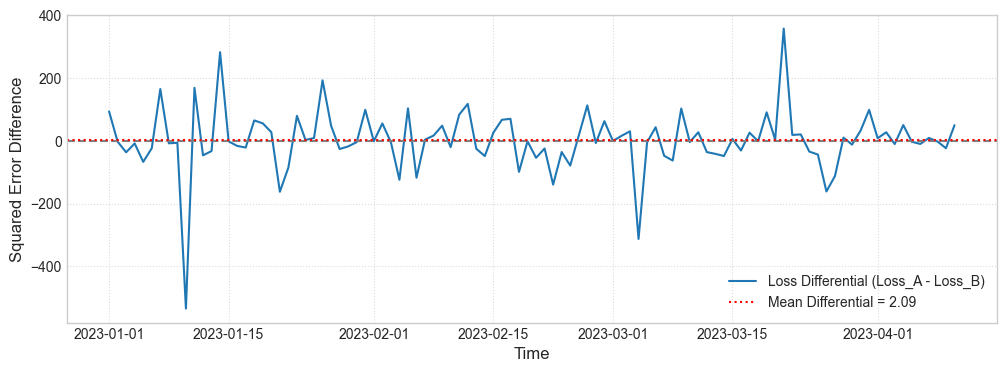

In [44]:
# Visualize the Loss Differential Series ---
loss_differential = errors_A**2 - errors_B**2
mean_diff = loss_differential.mean()

plt.figure(figsize=(12, 4))
plt.plot(loss_differential, label='Loss Differential (Loss_A - Loss_B)')
plt.axhline(0, color='grey', linestyle='--')
plt.axhline(mean_diff, color='red', linestyle=':', label=f'Mean Differential = {mean_diff:.2f}')
plt.title('Loss Differential Series for Diebold-Mariano Test', fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Squared Error Difference', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()